In [ ]:
# =========================
# 1. MOUNT GOOGLE DRIVE
# =========================
from google.colab import drive
drive.mount('/content/drive')

# =========================
# 2. IMPORTS
# =========================
import os, random, shutil
import numpy as np
from PIL import Image
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import classification_report

# =========================
# 3. PATHS (FIXED FOR YOUR DRIVE)
# =========================
ROOT_DIR = "/content/drive/MyDrive/Data Set /Dataset"   # ONLY potato/tomato/apple
WORK_DIR = "/content/processed_data"

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS = 20
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# =========================
# 4. VERIFY DATASET
# =========================
print("Crops found:", os.listdir(ROOT_DIR))

# =========================
# 5. FIND CLASS (LEAF) DIRECTORIES
# =========================
def get_class_dirs(root):
    class_dirs = []
    for r, d, f in os.walk(root):
        imgs = [x for x in f if x.lower().endswith(('.jpg','.jpeg','.png'))]
        if imgs:
            class_dirs.append(r)
    return class_dirs

class_dirs = get_class_dirs(ROOT_DIR)
print("Total disease classes found:", len(class_dirs))

# =========================
# 6. REMOVE CORRUPTED IMAGES (SAFE)
# =========================
def clean_images(class_dirs):
    removed = 0
    for d in class_dirs:
        for f in os.listdir(d):
            p = os.path.join(d, f)
            if not os.path.isfile(p):
                continue
            try:
                Image.open(p).verify()
            except:
                os.remove(p)
                removed += 1
    print("Corrupted images removed:", removed)

clean_images(class_dirs)

# =========================
# 7. CREATE 80 / 10 / 10 SPLIT
# =========================
if os.path.exists(WORK_DIR):
    shutil.rmtree(WORK_DIR)

for split in ["train", "val", "test"]:
    os.makedirs(os.path.join(WORK_DIR, split))

for cls_dir in class_dirs:
    class_name = cls_dir.replace(ROOT_DIR, "").strip("/").replace("/", "_")

    images = [f for f in os.listdir(cls_dir)
              if f.lower().endswith(('.jpg','.jpeg','.png'))]

    random.shuffle(images)
    n = len(images)
    t1 = int(0.8 * n)
    t2 = int(0.9 * n)

    split_map = {
        "train": images[:t1],
        "val": images[t1:t2],
        "test": images[t2:]
    }

    for split, files in split_map.items():
        out_dir = os.path.join(WORK_DIR, split, class_name)
        os.makedirs(out_dir, exist_ok=True)
        for f in files:
            shutil.copy(
                os.path.join(cls_dir, f),
                os.path.join(out_dir, f)
            )

print("Dataset split completed (80/10/10)")

# =========================
# 8. DATA GENERATORS (FIXED)
# =========================
datagen = tf.keras.preprocessing.image.ImageDataGenerator(rescale=1./255)

train_gen = datagen.flow_from_directory(
    directory=WORK_DIR + "/train",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=True
)

val_gen = datagen.flow_from_directory(
    directory=WORK_DIR + "/val",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

test_gen = datagen.flow_from_directory(
    directory=WORK_DIR + "/test",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

# =========================
# 9. MODEL (MOBILENETV2)
# =========================
base_model = MobileNetV2(
    input_shape=(224,224,3),
    include_top=False,
    weights="imagenet"
)
base_model.trainable = False

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(train_gen.num_classes, activation="softmax")
])

model.compile(
    optimizer=Adam(1e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

# =========================
# 10. TRAIN
# =========================
model.fit(
    train_gen,
    epochs=EPOCHS,
    validation_data=val_gen
)

# =========================
# 11. TEST + REPORT
# =========================
model.evaluate(test_gen)

y_true = test_gen.classes
y_pred = np.argmax(model.predict(test_gen), axis=1)

print(classification_report(
    y_true,
    y_pred,
    target_names=list(train_gen.class_indices.keys())
))

# =========================
# 12. SAVE MODEL
# =========================
model.save("/content/drive/MyDrive/multicrop_disease_model.h5")
print("Model saved successfully")

Mounted at /content/drive
Crops found: ['tomato', 'potato', 'apple', 'Strawberry']
Total disease classes found: 13
Corrupted images removed: 0
Dataset split completed (80/10/10)
Found 8626 images belonging to 13 classes.
Found 1077 images belonging to 13 classes.
Found 1084 images belonging to 13 classes.
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 13)             │         3,341 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,589,261 (9.88 MB)

 Trainable params: 331,277 (1.26 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


270/270 ━━━━━━━━━━━━━━━━━━━━ 500s 2s/step - accuracy: 0.4067 - loss: 1.8992 - val_accuracy: 0.8774 - val_loss: 0.5436
Epoch 2/20
270/270 ━━━━━━━━━━━━━━━━━━━━ 488s 2s/step - accuracy: 0.8181 - loss: 0.6066 - val_accuracy: 0.9136 - val_loss: 0.3106
Epoch 3/20
270/270 ━━━━━━━━━━━━━━━━━━━━ 483s 2s/step - accuracy: 0.8863 - loss: 0.3764 - val_accuracy: 0.9396 - val_loss: 0.2297
Epoch 4/20
270/270 ━━━━━━━━━━━━━━━━━━━━ 483s 2s/step - accuracy: 0.9162 - loss: 0.2827 - val_accuracy: 0.9508 - val_loss: 0.1855
Epoch 5/20
270/270 ━━━━━━━━━━━━━━━━━━━━ 464s 2s/step - accuracy: 0.9318 - loss: 0.2261 - val_accuracy: 0.9499 - val_loss: 0.1608
Epoch 6/20
270/270 ━━━━━━━━━━━━━━━━━━━━ 514s 2s/step - accuracy: 0.9431 - loss: 0.1934 - val_accuracy: 0.9629 - val_loss: 0.1379
Epoch 7/20
270/270 ━━━━━━━━━━━━━━━━━━━━ 477s 2s/step - accuracy: 0.9574 - loss: 0.1624 - val_accuracy: 0.9591 - val_loss: 0.1321
Epoch 8/20
270/270 ━━━━━━━━━━━━━━━━━━━━ 513s 2s/step - accuracy: 0.9574 - loss: 0.1506 - val_accuracy: 0.962

                                     precision    recall  f1-score   support

Strawberry_Strawberry___Leaf_scorch       1.00      1.00      1.00       111
    Strawberry_Strawberry___healthy       1.00      1.00      1.00        46
           apple_Apple___Apple_scab       0.97      0.93      0.95        61
            apple_Apple___Black_rot       1.00      1.00      1.00        63
     apple_Apple___Cedar_apple_rust       0.97      1.00      0.98        28
              apple_Apple___healthy       0.99      0.99      0.99       165
       potato_Potato___Early_blight       0.99      0.99      0.99       100
        potato_Potato___Late_blight       0.93      0.97      0.95       100
            potato_Potato___healthy       0.93      0.81      0.87        16
       tomato_Tomato___Early_blight       0.97      0.90      0.93       100
          tomato_Tomato___Leaf_Mold       0.94      0.99      0.96        96
tomato_Tomato___Tomato_mosaic_virus       1.00      1.00      1.00        3

34/34 ━━━━━━━━━━━━━━━━━━━━ 54s 2s/step


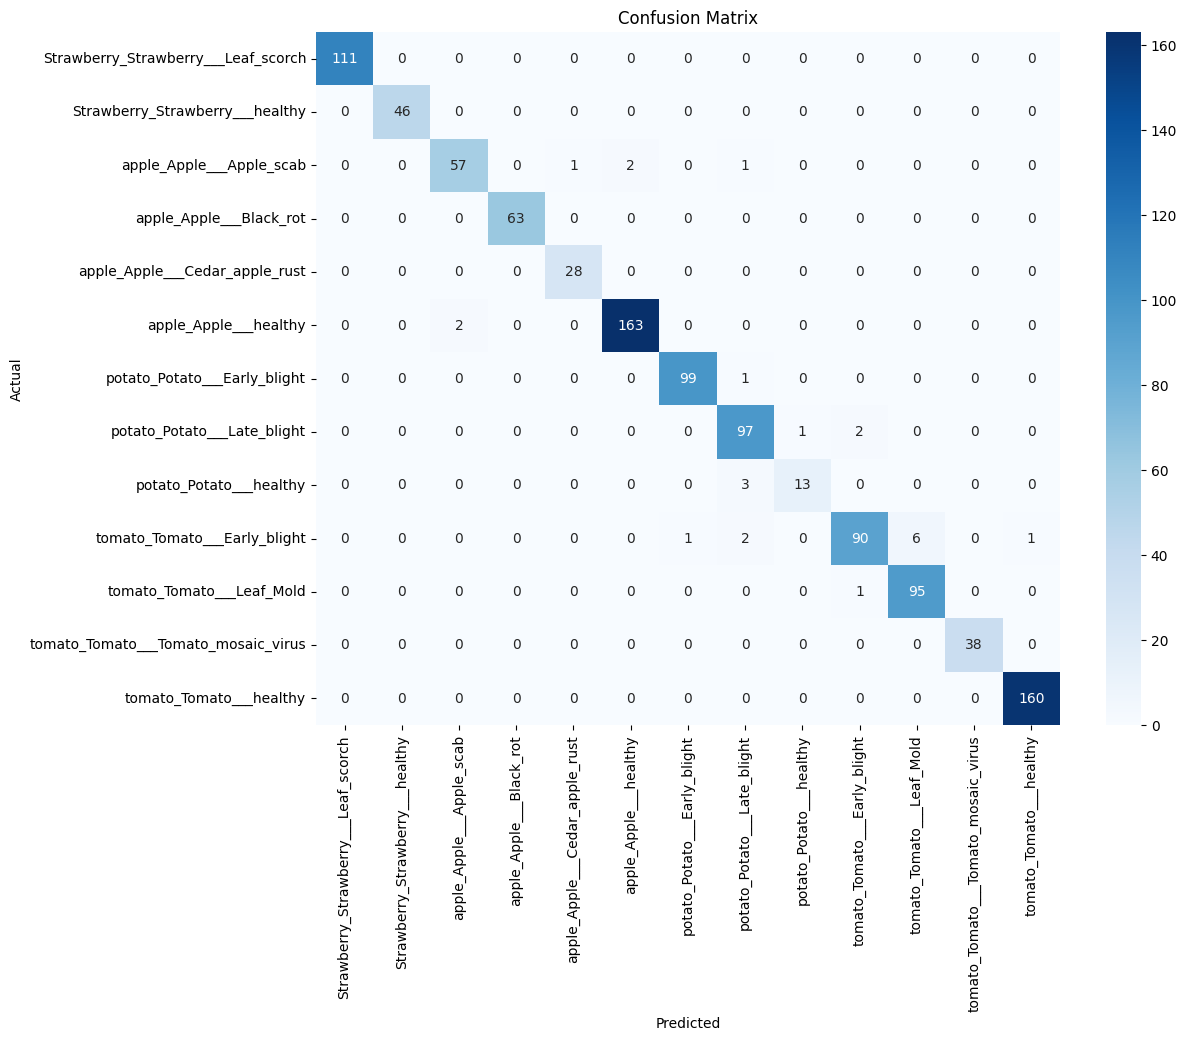

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

y_true = test_gen.classes
y_pred = np.argmax(model.predict(test_gen), axis=1)

cm = confusion_matrix(y_true, y_pred)
class_names = list(train_gen.class_indices.keys())

plt.figure(figsize=(12, 9))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=class_names,
            yticklabels=class_names,
            cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Found 8626 images belonging to 13 classes.
Found 1077 images belonging to 13 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
270/270 ━━━━━━━━━━━━━━━━━━━━ 412s 1s/step - accuracy: 0.9444 - loss: 0.1575 - val_accuracy: 0.9591 - val_loss: 0.1229
Epoch 2/20
270/270 ━━━━━━━━━━━━━━━━━━━━ 477s 2s/step - accuracy: 0.9605 - loss: 0.1129 - val_accuracy: 0.9647 - val_loss: 0.0971
Epoch 3/20
270/270 ━━━━━━━━━━━━━━━━━━━━ 430s 2s/step - accuracy: 0.9676 - loss: 0.0865 - val_accuracy: 0.9759 - val_loss: 0.0713
Epoch 4/20
270/270 ━━━━━━━━━━━━━━━━━━━━ 390s 1s/step - accuracy: 0.9716 - loss: 0.0772 - val_accuracy: 0.9721 - val_loss: 0.0781
Epoch 5/20
270/270 ━━━━━━━━━━━━━━━━━━━━ 391s 1s/step - accuracy: 0.9774 - loss: 0.0640 - val_accuracy: 0.9712 - val_loss: 0.0735
Epoch 6/20
270/270 ━━━━━━━━━━━━━━━━━━━━ 385s 1s/step - accuracy: 0.9756 - loss: 0.0687 - val_accuracy: 0.9712 - val_loss: 0.0785
Epoch 7/20
270/270 ━━━━━━━━━━━━━━━━━━━━ 428s 2s/step - accuracy: 0.9798 - loss: 0.0622 - val_accuracy: 0.9656 - val_loss: 0.0923
Epoch 8/20
270/270 ━━━━━━━━━━━━━━━━━━━━ 386s 1s/step - accuracy: 0.9830 - loss: 0.0512 - val_accu

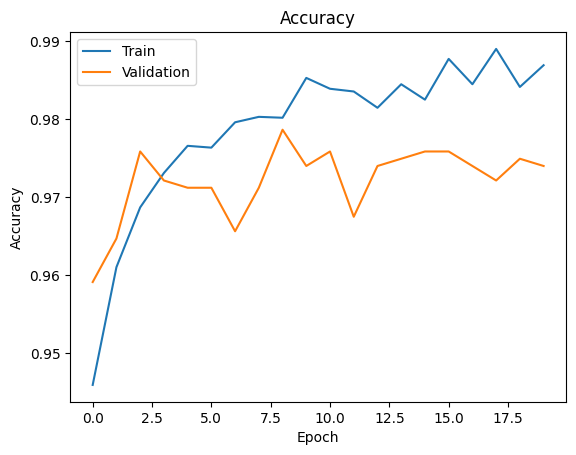

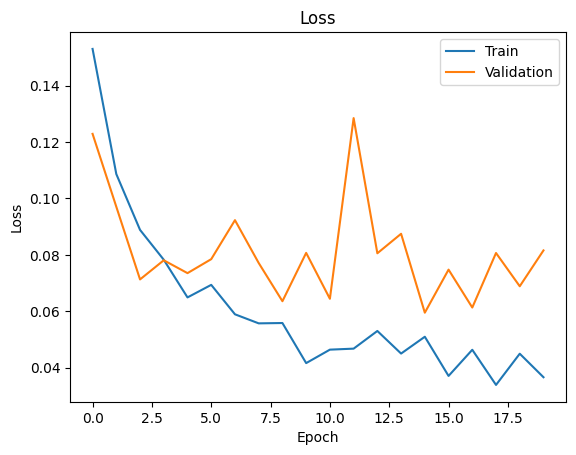

Done.


In [ ]:
# =========================
# FULL PIPELINE + RETRAIN + CURVES (TRUE SINGLE CELL)
# =========================

from google.colab import drive
drive.mount('/content/drive')

import os, random, shutil
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from PIL import Image
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import load_model

# Paths
ROOT_DIR = "/content/drive/MyDrive/Data Set /Dataset"
WORK_DIR = "/content/processed_data"
IMG_SIZE = (224,224)
BATCH_SIZE = 32
EPOCHS = 20
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Clean old split
if os.path.exists(WORK_DIR):
    shutil.rmtree(WORK_DIR)

for split in ["train","val","test"]:
    os.makedirs(os.path.join(WORK_DIR, split))

# Find class folders
class_dirs = []
for r,d,f in os.walk(ROOT_DIR):
    imgs = [x for x in f if x.lower().endswith(('.jpg','.png','.jpeg'))]
    if imgs:
        class_dirs.append(r)

# Split 80/10/10
for cls_dir in class_dirs:
    class_name = cls_dir.replace(ROOT_DIR,"").strip("/").replace("/","_")
    images = [f for f in os.listdir(cls_dir)
              if f.lower().endswith(('.jpg','.png','.jpeg'))]
    random.shuffle(images)
    n = len(images)
    t1 = int(0.8*n)
    t2 = int(0.9*n)

    split_map = {
        "train": images[:t1],
        "val": images[t1:t2],
        "test": images[t2:]
    }

    for split, files in split_map.items():
        out_dir = os.path.join(WORK_DIR, split, class_name)
        os.makedirs(out_dir, exist_ok=True)
        for f in files:
            shutil.copy(os.path.join(cls_dir,f),
                        os.path.join(out_dir,f))

# Generators
datagen = ImageDataGenerator(rescale=1./255)

train_gen = datagen.flow_from_directory(
    WORK_DIR+"/train",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=True
)

val_gen = datagen.flow_from_directory(
    WORK_DIR+"/val",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

# Load existing model
model = load_model("/content/drive/MyDrive/multicrop_disease_model.h5")

model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

# Retrain
history = model.fit(
    train_gen,
    epochs=EPOCHS,
    validation_data=val_gen
)

# Accuracy Curve
plt.figure()
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Train","Validation"])
plt.show()

# Loss Curve
plt.figure()
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(["Train","Validation"])
plt.show()

print("Done.")

In [ ]:
# =========================
# INSTALL + IMPORTS
# =========================
!pip -q install optuna

import optuna
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adam

# =========================
# OBJECTIVE FUNCTION (TPE)
# =========================
def objective(trial):

    lr = trial.suggest_float("lr", 1e-5, 1e-3, log=True)
    dropout = trial.suggest_float("dropout", 0.2, 0.6)
    batch_size = trial.suggest_categorical("batch_size", [16, 32, 64])
    fine_tune_layers = trial.suggest_int("fine_tune_layers", 20, 120)

    datagen = tf.keras.preprocessing.image.ImageDataGenerator(
        rescale=1./255,
        rotation_range=20,
        zoom_range=0.2,
        horizontal_flip=True
    )

    train_gen = datagen.flow_from_directory(
        WORK_DIR + "/train",
        target_size=IMG_SIZE,
        batch_size=batch_size,
        class_mode="categorical",
        shuffle=True
    )

    val_gen = datagen.flow_from_directory(
        WORK_DIR + "/val",
        target_size=IMG_SIZE,
        batch_size=batch_size,
        class_mode="categorical",
        shuffle=False
    )

    base_model = MobileNetV2(
        input_shape=(224,224,3),
        include_top=False,
        weights="imagenet"
    )

    for layer in base_model.layers:
        layer.trainable = False

    for layer in base_model.layers[-fine_tune_layers:]:
        layer.trainable = True

    model = models.Sequential([
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.Dense(256, activation="relu"),
        layers.Dropout(dropout),
        layers.Dense(train_gen.num_classes, activation="softmax")
    ])

    model.compile(
        optimizer=Adam(learning_rate=lr),
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

    early_stop = tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=2,
        restore_best_weights=True
    )

    history = model.fit(
        train_gen,
        epochs=6,
        validation_data=val_gen,
        callbacks=[early_stop],
        verbose=0
    )

    return max(history.history["val_accuracy"])


# =========================
# RUN TPE
# =========================
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=15)

print("\n🔥 BEST PARAMETERS:")
print(study.best_params)
print("Best Accuracy:", study.best_value)


# =========================
# FINAL TRAIN WITH BEST PARAMS
# =========================
best = study.best_params

datagen = tf.keras.preprocessing.image.ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

train_gen = datagen.flow_from_directory(
    WORK_DIR + "/train",
    target_size=IMG_SIZE,
    batch_size=best["batch_size"],
    class_mode="categorical",
    shuffle=True
)

val_gen = datagen.flow_from_directory(
    WORK_DIR + "/val",
    target_size=IMG_SIZE,
    batch_size=best["batch_size"],
    class_mode="categorical",
    shuffle=False
)

test_gen = datagen.flow_from_directory(
    WORK_DIR + "/test",
    target_size=IMG_SIZE,
    batch_size=best["batch_size"],
    class_mode="categorical",
    shuffle=False
)

base_model = MobileNetV2(
    input_shape=(224,224,3),
    include_top=False,
    weights="imagenet"
)

for layer in base_model.layers:
    layer.trainable = False

for layer in base_model.layers[-best["fine_tune_layers"]:]:
    layer.trainable = True

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation="relu"),
    layers.Dropout(best["dropout"]),
    layers.Dense(train_gen.num_classes, activation="softmax")
])

model.compile(
    optimizer=Adam(learning_rate=best["lr"]),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

print("\n🚀 FINAL TRAINING...")
model.fit(
    train_gen,
    epochs=20,
    validation_data=val_gen
)

print("\n📊 TEST PERFORMANCE:")
model.evaluate(test_gen)

model.save("/content/drive/MyDrive/multicrop_disease_model_tpe.h5")
print("✅ Model saved with TPE optimization!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 13.2 MB/s eta 0:00:00


[I 2026-04-10 06:07:07,096] A new study created in memory with name: no-name-a7f1d8a2-344d-4ace-a44d-4353257d9634
[W 2026-04-10 06:07:07,099] Trial 0 failed with parameters: {'lr': 0.00013654352379484995, 'dropout': 0.42646608843379274, 'batch_size': 16, 'fine_tune_layers': 31} because of the following error: NameError("name 'WORK_DIR' is not defined").
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/optuna/study/_optimize.py", line 206, in _run_trial
    value_or_values = func(trial)
                      ^^^^^^^^^^^
  File "/tmp/ipykernel_3213/3254343624.py", line 30, in objective
    WORK_DIR + "/train",
    ^^^^^^^^
NameError: name 'WORK_DIR' is not defined
[W 2026-04-10 06:07:07,102] Trial 0 failed with value None.


NameError: name 'WORK_DIR' is not defined

In [ ]:
# =========================
# INSTALL
# =========================
!pip -q install optuna

# =========================
# IMPORTS
# =========================
import optuna
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adam

# =========================
# REQUIRED VARIABLES (FIX)
# =========================
WORK_DIR = "/content/processed_data"   # IMPORTANT: same as your earlier split
IMG_SIZE = (224, 224)

# =========================
# OBJECTIVE FUNCTION (TPE)
# =========================
def objective(trial):

    lr = trial.suggest_float("lr", 1e-5, 1e-3, log=True)
    dropout = trial.suggest_float("dropout", 0.2, 0.6)
    batch_size = trial.suggest_categorical("batch_size", [16, 32, 64])
    fine_tune_layers = trial.suggest_int("fine_tune_layers", 20, 120)

    datagen = tf.keras.preprocessing.image.ImageDataGenerator(
        rescale=1./255,
        rotation_range=20,
        zoom_range=0.2,
        horizontal_flip=True
    )

    train_gen = datagen.flow_from_directory(
        WORK_DIR + "/train",
        target_size=IMG_SIZE,
        batch_size=batch_size,
        class_mode="categorical",
        shuffle=True
    )

    val_gen = datagen.flow_from_directory(
        WORK_DIR + "/val",
        target_size=IMG_SIZE,
        batch_size=batch_size,
        class_mode="categorical",
        shuffle=False
    )

    base_model = MobileNetV2(
        input_shape=(224,224,3),
        include_top=False,
        weights="imagenet"
    )

    # Freeze all layers
    for layer in base_model.layers:
        layer.trainable = False

    # Fine-tune last N layers
    for layer in base_model.layers[-fine_tune_layers:]:
        layer.trainable = True

    model = models.Sequential([
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.Dense(256, activation="relu"),
        layers.Dropout(dropout),
        layers.Dense(train_gen.num_classes, activation="softmax")
    ])

    model.compile(
        optimizer=Adam(learning_rate=lr),
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

    early_stop = tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=2,
        restore_best_weights=True
    )

    history = model.fit(
        train_gen,
        epochs=5,
        validation_data=val_gen,
        callbacks=[early_stop],
        verbose=0
    )

    return max(history.history["val_accuracy"])


# =========================
# RUN TPE
# =========================
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=15)

print("\n🔥 BEST PARAMETERS:")
print(study.best_params)
print("Best Accuracy:", study.best_value)


# =========================
# FINAL TRAINING
# =========================
best = study.best_params

datagen = tf.keras.preprocessing.image.ImageDataGenerator(rescale=1./255)

train_gen = datagen.flow_from_directory(
    WORK_DIR + "/train",
    target_size=IMG_SIZE,
    batch_size=best["batch_size"],
    class_mode="categorical",
    shuffle=True
)

val_gen = datagen.flow_from_directory(
    WORK_DIR + "/val",
    target_size=IMG_SIZE,
    batch_size=best["batch_size"],
    class_mode="categorical",
    shuffle=False
)

test_gen = datagen.flow_from_directory(
    WORK_DIR + "/test",
    target_size=IMG_SIZE,
    batch_size=best["batch_size"],
    class_mode="categorical",
    shuffle=False
)

base_model = MobileNetV2(
    input_shape=(224,224,3),
    include_top=False,
    weights="imagenet"
)

for layer in base_model.layers:
    layer.trainable = False

for layer in base_model.layers[-best["fine_tune_layers"]:]:
    layer.trainable = True

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation="relu"),
    layers.Dropout(best["dropout"]),
    layers.Dense(train_gen.num_classes, activation="softmax")
])

model.compile(
    optimizer=Adam(learning_rate=best["lr"]),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

print("\n🚀 FINAL TRAINING...")
model.fit(
    train_gen,
    epochs=20,
    validation_data=val_gen
)

print("\n📊 TEST PERFORMANCE:")
model.evaluate(test_gen)

[I 2026-04-10 06:08:56,559] A new study created in memory with name: no-name-3d37de15-1b7f-4611-9dc3-e952f8760e88
[W 2026-04-10 06:08:56,563] Trial 0 failed with parameters: {'lr': 8.507347461112455e-05, 'dropout': 0.5686735505300572, 'batch_size': 16, 'fine_tune_layers': 68} because of the following error: FileNotFoundError(2, 'No such file or directory').
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/optuna/study/_optimize.py", line 206, in _run_trial
    value_or_values = func(trial)
                      ^^^^^^^^^^^
  File "/tmp/ipykernel_3213/3338235768.py", line 38, in objective
    train_gen = datagen.flow_from_directory(
                ^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/keras/src/legacy/preprocessing/image.py", line 1136, in flow_from_directory
    return DirectoryIterator(
           ^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/keras/src/legacy/preprocessing/image.py", line 45

FileNotFoundError: [Errno 2] No such file or directory: '/content/processed_data/train'

In [ ]:
# =========================
# 1. SETUP
# =========================
!pip -q install optuna

from google.colab import drive
drive.mount('/content/drive')

import os, random, shutil
import numpy as np
from PIL import Image
import tensorflow as tf
import optuna

from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adam

# =========================
# 2. PATHS
# =========================
ROOT_DIR = "/content/drive/MyDrive/Data Set /Dataset"
WORK_DIR = "/content/processed_data"
IMG_SIZE = (224, 224)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# =========================
# 3. CREATE DATASET (IF NOT EXISTS)
# =========================
if not os.path.exists(WORK_DIR + "/train"):

    print("⚙️ Creating dataset split...")

    def get_class_dirs(root):
        class_dirs = []
        for r, d, f in os.walk(root):
            imgs = [x for x in f if x.lower().endswith(('.jpg','.jpeg','.png'))]
            if imgs:
                class_dirs.append(r)
        return class_dirs

    class_dirs = get_class_dirs(ROOT_DIR)

    # clean corrupted
    for d in class_dirs:
        for f in os.listdir(d):
            p = os.path.join(d, f)
            try:
                Image.open(p).verify()
            except:
                os.remove(p)

    if os.path.exists(WORK_DIR):
        shutil.rmtree(WORK_DIR)

    for split in ["train", "val", "test"]:
        os.makedirs(os.path.join(WORK_DIR, split))

    for cls_dir in class_dirs:
        class_name = cls_dir.replace(ROOT_DIR, "").strip("/").replace("/", "_")

        images = [f for f in os.listdir(cls_dir)
                  if f.lower().endswith(('.jpg','.jpeg','.png'))]

        random.shuffle(images)
        n = len(images)
        t1 = int(0.8 * n)
        t2 = int(0.9 * n)

        split_map = {
            "train": images[:t1],
            "val": images[t1:t2],
            "test": images[t2:]
        }

        for split, files in split_map.items():
            out_dir = os.path.join(WORK_DIR, split, class_name)
            os.makedirs(out_dir, exist_ok=True)
            for f in files:
                shutil.copy(os.path.join(cls_dir, f), os.path.join(out_dir, f))

    print("✅ Dataset ready")

# =========================
# 4. TPE OBJECTIVE
# =========================
def objective(trial):

    lr = trial.suggest_float("lr", 1e-5, 1e-3, log=True)
    dropout = trial.suggest_float("dropout", 0.2, 0.6)
    batch_size = trial.suggest_categorical("batch_size", [16, 32, 64])
    fine_tune_layers = trial.suggest_int("fine_tune_layers", 20, 120)

    datagen = tf.keras.preprocessing.image.ImageDataGenerator(
        rescale=1./255,
        rotation_range=20,
        zoom_range=0.2,
        horizontal_flip=True
    )

    train_gen = datagen.flow_from_directory(
        WORK_DIR + "/train",
        target_size=IMG_SIZE,
        batch_size=batch_size,
        class_mode="categorical"
    )

    val_gen = datagen.flow_from_directory(
        WORK_DIR + "/val",
        target_size=IMG_SIZE,
        batch_size=batch_size,
        class_mode="categorical"
    )

    base_model = MobileNetV2(input_shape=(224,224,3), include_top=False, weights="imagenet")

    for layer in base_model.layers:
        layer.trainable = False
    for layer in base_model.layers[-fine_tune_layers:]:
        layer.trainable = True

    model = models.Sequential([
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.Dense(256, activation="relu"),
        layers.Dropout(dropout),
        layers.Dense(train_gen.num_classes, activation="softmax")
    ])

    model.compile(optimizer=Adam(lr), loss="categorical_crossentropy", metrics=["accuracy"])

    history = model.fit(train_gen, epochs=5, validation_data=val_gen, verbose=0)

    return max(history.history["val_accuracy"])

# =========================
# 5. RUN TPE
# =========================
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=15)

print("\n🔥 BEST PARAMS:", study.best_params)

# =========================
# 6. FINAL TRAINING
# =========================
best = study.best_params

datagen = tf.keras.preprocessing.image.ImageDataGenerator(rescale=1./255)

train_gen = datagen.flow_from_directory(
    WORK_DIR + "/train",
    target_size=IMG_SIZE,
    batch_size=best["batch_size"],
    class_mode="categorical"
)

val_gen = datagen.flow_from_directory(
    WORK_DIR + "/val",
    target_size=IMG_SIZE,
    batch_size=best["batch_size"],
    class_mode="categorical"
)

test_gen = datagen.flow_from_directory(
    WORK_DIR + "/test",
    target_size=IMG_SIZE,
    batch_size=best["batch_size"],
    class_mode="categorical"
)

base_model = MobileNetV2(input_shape=(224,224,3), include_top=False, weights="imagenet")

for layer in base_model.layers:
    layer.trainable = False
for layer in base_model.layers[-best["fine_tune_layers"]:]:
    layer.trainable = True

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation="relu"),
    layers.Dropout(best["dropout"]),
    layers.Dense(train_gen.num_classes, activation="softmax")
])

model.compile(optimizer=Adam(best["lr"]), loss="categorical_crossentropy", metrics=["accuracy"])

print("\n🚀 Final Training...")
model.fit(train_gen, epochs=20, validation_data=val_gen)

print("\n📊 Test Accuracy:")
model.evaluate(test_gen)

model.save("/content/drive/MyDrive/multicrop_disease_model_tpe.h5")
print("✅ Model saved!")

Mounted at /content/drive
⚙️ Creating dataset split...


FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/Data Set /Dataset/tomato/Tomato___Tomato_mosaic_virus'

In [ ]:
# =========================
# 1. SETUP
# =========================
!pip -q install optuna

from google.colab import drive
drive.mount('/content/drive')

import os, random, shutil
import numpy as np
from PIL import Image
import tensorflow as tf
import optuna

from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adam

# =========================
# 2. PATHS
# =========================
ROOT_DIR = "/content/drive/MyDrive/Data Set /Dataset"
WORK_DIR = "/content/processed_data"
IMG_SIZE = (224, 224)

# =========================
# 3. SAFE DATASET PREP
# =========================
if not os.path.exists(WORK_DIR + "/train"):

    print("⚙️ Preparing dataset safely...")

    class_dirs = []

    # find valid folders ONLY
    for r, d, f in os.walk(ROOT_DIR):
        if len(f) > 0:
            imgs = [x for x in f if x.lower().endswith(('.jpg','.jpeg','.png'))]
            if len(imgs) > 0:
                class_dirs.append(r)

    print("Raw classes found:", len(class_dirs))

    valid_dirs = []

    # clean + validate
    for d in class_dirs:
        if not os.path.exists(d):
            continue

        try:
            files = os.listdir(d)
        except:
            continue

        if len(files) == 0:
            continue

        cleaned = []
        for f in files:
            p = os.path.join(d, f)
            try:
                Image.open(p).verify()
                cleaned.append(f)
            except:
                try:
                    os.remove(p)
                except:
                    pass

        if len(cleaned) > 5:   # keep only meaningful classes
            valid_dirs.append((d, cleaned))

    print("Valid classes after cleaning:", len(valid_dirs))

    # recreate WORK_DIR
    if os.path.exists(WORK_DIR):
        shutil.rmtree(WORK_DIR)

    for split in ["train", "val", "test"]:
        os.makedirs(os.path.join(WORK_DIR, split))

    # split data
    for cls_dir, images in valid_dirs:

        class_name = cls_dir.replace(ROOT_DIR, "").strip("/").replace("/", "_")

        random.shuffle(images)
        n = len(images)

        t1 = int(0.8 * n)
        t2 = int(0.9 * n)

        split_map = {
            "train": images[:t1],
            "val": images[t1:t2],
            "test": images[t2:]
        }

        for split, files in split_map.items():
            out_dir = os.path.join(WORK_DIR, split, class_name)
            os.makedirs(out_dir, exist_ok=True)

            for f in files:
                src = os.path.join(cls_dir, f)
                dst = os.path.join(out_dir, f)
                try:
                    shutil.copy(src, dst)
                except:
                    continue

    print("✅ Dataset ready")

# =========================
# 4. TPE OBJECTIVE
# =========================
def objective(trial):

    lr = trial.suggest_float("lr", 1e-5, 1e-3, log=True)
    dropout = trial.suggest_float("dropout", 0.2, 0.6)
    batch_size = trial.suggest_categorical("batch_size", [16, 32, 64])
    fine_tune_layers = trial.suggest_int("fine_tune_layers", 20, 120)

    datagen = tf.keras.preprocessing.image.ImageDataGenerator(
        rescale=1./255,
        rotation_range=20,
        zoom_range=0.2,
        horizontal_flip=True
    )

    train_gen = datagen.flow_from_directory(
        WORK_DIR + "/train",
        target_size=IMG_SIZE,
        batch_size=batch_size,
        class_mode="categorical"
    )

    val_gen = datagen.flow_from_directory(
        WORK_DIR + "/val",
        target_size=IMG_SIZE,
        batch_size=batch_size,
        class_mode="categorical"
    )

    base_model = MobileNetV2(input_shape=(224,224,3), include_top=False, weights="imagenet")

    for layer in base_model.layers:
        layer.trainable = False

    for layer in base_model.layers[-fine_tune_layers:]:
        layer.trainable = True

    model = models.Sequential([
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.Dense(256, activation="relu"),
        layers.Dropout(dropout),
        layers.Dense(train_gen.num_classes, activation="softmax")
    ])

    model.compile(
        optimizer=Adam(lr),
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

    history = model.fit(
        train_gen,
        epochs=5,
        validation_data=val_gen,
        verbose=0
    )

    return max(history.history["val_accuracy"])

# =========================
# 5. RUN TPE
# =========================
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=15)

print("\n🔥 BEST PARAMS:", study.best_params)

# =========================
# 6. FINAL TRAIN
# =========================
best = study.best_params

datagen = tf.keras.preprocessing.image.ImageDataGenerator(rescale=1./255)

train_gen = datagen.flow_from_directory(
    WORK_DIR + "/train",
    target_size=IMG_SIZE,
    batch_size=best["batch_size"],
    class_mode="categorical"
)

val_gen = datagen.flow_from_directory(
    WORK_DIR + "/val",
    target_size=IMG_SIZE,
    batch_size=best["batch_size"],
    class_mode="categorical"
)

test_gen = datagen.flow_from_directory(
    WORK_DIR + "/test",
    target_size=IMG_SIZE,
    batch_size=best["batch_size"],
    class_mode="categorical"
)

base_model = MobileNetV2(input_shape=(224,224,3), include_top=False, weights="imagenet")

for layer in base_model.layers:
    layer.trainable = False

for layer in base_model.layers[-best["fine_tune_layers"]:]:
    layer.trainable = True

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation="relu"),
    layers.Dropout(best["dropout"]),
    layers.Dense(train_gen.num_classes, activation="softmax")
])

model.compile(
    optimizer=Adam(best["lr"]),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

print("\n🚀 Final Training...")
model.fit(train_gen, epochs=20, validation_data=val_gen)

print("\n📊 Test Accuracy:")
model.evaluate(test_gen)

model.save("/content/drive/MyDrive/multicrop_disease_model_tpe.h5")
print("✅ Model saved!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
⚙️ Preparing dataset safely...
Raw classes found: 13


In [ ]:
# =========================
# 1. SETUP
# =========================
!pip -q install optuna

from google.colab import drive
drive.mount('/content/drive')

import os, random, shutil
import numpy as np
from PIL import Image
import tensorflow as tf
import optuna

from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adam

# =========================
# 2. PATHS
# =========================
ROOT_DIR = "/content/drive/MyDrive/Data Set /Dataset"
WORK_DIR = "/content/processed_data"
IMG_SIZE = (224, 224)

# =========================
# 3. SAFE DATASET PREP
# =========================
if not os.path.exists(WORK_DIR + "/train"):

    print("⚙️ Preparing dataset safely...")

    class_dirs = []

    # find valid folders ONLY
    for r, d, f in os.walk(ROOT_DIR):
        if len(f) > 0:
            imgs = [x for x in f if x.lower().endswith(('.jpg','.jpeg','.png'))]
            if len(imgs) > 0:
                class_dirs.append(r)

    print("Raw classes found:", len(class_dirs))

    valid_dirs = []

    # clean + validate
    for d in class_dirs:
        if not os.path.exists(d):
            continue

        try:
            files = os.listdir(d)
        except:
            continue

        if len(files) == 0:
            continue

        cleaned = []
        for f in files:
            p = os.path.join(d, f)
            try:
                Image.open(p).verify()
                cleaned.append(f)
            except:
                try:
                    os.remove(p)
                except:
                    pass

        if len(cleaned) > 5:   # keep only meaningful classes
            valid_dirs.append((d, cleaned))

    print("Valid classes after cleaning:", len(valid_dirs))

    # recreate WORK_DIR
    if os.path.exists(WORK_DIR):
        shutil.rmtree(WORK_DIR)

    for split in ["train", "val", "test"]:
        os.makedirs(os.path.join(WORK_DIR, split))

    # split data
    for cls_dir, images in valid_dirs:

        class_name = cls_dir.replace(ROOT_DIR, "").strip("/").replace("/", "_")

        random.shuffle(images)
        n = len(images)

        t1 = int(0.8 * n)
        t2 = int(0.9 * n)

        split_map = {
            "train": images[:t1],
            "val": images[t1:t2],
            "test": images[t2:]
        }

        for split, files in split_map.items():
            out_dir = os.path.join(WORK_DIR, split, class_name)
            os.makedirs(out_dir, exist_ok=True)

            for f in files:
                src = os.path.join(cls_dir, f)
                dst = os.path.join(out_dir, f)
                try:
                    shutil.copy(src, dst)
                except:
                    continue

    print("✅ Dataset ready")

# =========================
# 4. TPE OBJECTIVE
# =========================
def objective(trial):

    lr = trial.suggest_float("lr", 1e-5, 1e-3, log=True)
    dropout = trial.suggest_float("dropout", 0.2, 0.6)
    batch_size = trial.suggest_categorical("batch_size", [16, 32, 64])
    fine_tune_layers = trial.suggest_int("fine_tune_layers", 20, 120)

    datagen = tf.keras.preprocessing.image.ImageDataGenerator(
        rescale=1./255,
        rotation_range=20,
        zoom_range=0.2,
        horizontal_flip=True
    )

    train_gen = datagen.flow_from_directory(
        WORK_DIR + "/train",
        target_size=IMG_SIZE,
        batch_size=batch_size,
        class_mode="categorical"
    )

    val_gen = datagen.flow_from_directory(
        WORK_DIR + "/val",
        target_size=IMG_SIZE,
        batch_size=batch_size,
        class_mode="categorical"
    )

    base_model = MobileNetV2(input_shape=(224,224,3), include_top=False, weights="imagenet")

    for layer in base_model.layers:
        layer.trainable = False

    for layer in base_model.layers[-fine_tune_layers:]:
        layer.trainable = True

    model = models.Sequential([
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.Dense(256, activation="relu"),
        layers.Dropout(dropout),
        layers.Dense(train_gen.num_classes, activation="softmax")
    ])

    model.compile(
        optimizer=Adam(lr),
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

    history = model.fit(
        train_gen,
        epochs=5,
        validation_data=val_gen,
        verbose=0
    )

    return max(history.history["val_accuracy"])

# =========================
# 5. RUN TPE
# =========================
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=15)

print("\n🔥 BEST PARAMS:", study.best_params)

# =========================
# 6. FINAL TRAIN
# =========================
best = study.best_params

datagen = tf.keras.preprocessing.image.ImageDataGenerator(rescale=1./255)

train_gen = datagen.flow_from_directory(
    WORK_DIR + "/train",
    target_size=IMG_SIZE,
    batch_size=best["batch_size"],
    class_mode="categorical"
)

val_gen = datagen.flow_from_directory(
    WORK_DIR + "/val",
    target_size=IMG_SIZE,
    batch_size=best["batch_size"],
    class_mode="categorical"
)

test_gen = datagen.flow_from_directory(
    WORK_DIR + "/test",
    target_size=IMG_SIZE,
    batch_size=best["batch_size"],
    class_mode="categorical"
)

base_model = MobileNetV2(input_shape=(224,224,3), include_top=False, weights="imagenet")

for layer in base_model.layers:
    layer.trainable = False

for layer in base_model.layers[-best["fine_tune_layers"]:]:
    layer.trainable = True

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation="relu"),
    layers.Dropout(best["dropout"]),
    layers.Dense(train_gen.num_classes, activation="softmax")
])

model.compile(
    optimizer=Adam(best["lr"]),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

print("\n🚀 Final Training...")
model.fit(train_gen, epochs=20, validation_data=val_gen)

print("\n📊 Test Accuracy:")
model.evaluate(test_gen)

model.save("/content/drive/MyDrive/multicrop_disease_model_tpe.h5")
print("✅ Model saved!")

[I 2026-04-11 16:28:52,919] A new study created in memory with name: no-name-7b8f63d8-03b8-4bf6-867b-7217c2aa67af


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Found 0 images belonging to 0 classes.
Found 0 images belonging to 0 classes.


[W 2026-04-11 16:28:53,630] Trial 0 failed with parameters: {'lr': 7.359414775351118e-05, 'dropout': 0.4130090896792703, 'batch_size': 16, 'fine_tune_layers': 99} because of the following error: ValueError('Received an invalid value for `units`, expected a positive integer. Received: units=0').
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/optuna/study/_optimize.py", line 206, in _run_trial
    value_or_values = func(trial)
                      ^^^^^^^^^^^
  File "/tmp/ipykernel_447/3428156240.py", line 158, in objective
    layers.Dense(train_gen.num_classes, activation="softmax")
  File "/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py", line 101, in __init__
    raise ValueError(
ValueError: Received an invalid value for `units`, expected a positive integer. Received: units=0
[W 2026-04-11 16:28:53,631] Trial 0 failed with value None.


ValueError: Received an invalid value for `units`, expected a positive integer. Received: units=0

In [ ]:
# =========================
# 1. SETUP
# =========================
!pip -q install optuna

from google.colab import drive
drive.mount('/content/drive')

import os, random, shutil
import numpy as np
from PIL import Image
import tensorflow as tf
import optuna

from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adam

# =========================
# 2. PATHS
# =========================
ROOT_DIR = "/content/drive/MyDrive/Data Set /Dataset"
WORK_DIR = "/content/processed_data"
IMG_SIZE = (224, 224)

# =========================
# 3. SAFE DATASET PREP
# =========================
if not os.path.exists(WORK_DIR + "/train"):

    print("⚙️ Preparing dataset safely...")

    class_dirs = []

    # find valid folders ONLY
    for r, d, f in os.walk(ROOT_DIR):
        if len(f) > 0:
            imgs = [x for x in f if x.lower().endswith(('.jpg','.jpeg','.png'))]
            if len(imgs) > 0:
                class_dirs.append(r)

    print("Raw classes found:", len(class_dirs))

    valid_dirs = []

    # clean + validate
    for d in class_dirs:
        if not os.path.exists(d):
            continue

        try:
            files = os.listdir(d)
        except:
            continue

        if len(files) == 0:
            continue

        cleaned = []
        for f in files:
            p = os.path.join(d, f)
            try:
                Image.open(p).verify()
                cleaned.append(f)
            except:
                try:
                    os.remove(p)
                except:
                    pass

        if len(cleaned) > 5:   # keep only meaningful classes
            valid_dirs.append((d, cleaned))

    print("Valid classes after cleaning:", len(valid_dirs))

    # recreate WORK_DIR
    if os.path.exists(WORK_DIR):
        shutil.rmtree(WORK_DIR)

    for split in ["train", "val", "test"]:
        os.makedirs(os.path.join(WORK_DIR, split))

    # split data
    for cls_dir, images in valid_dirs:

        class_name = cls_dir.replace(ROOT_DIR, "").strip("/").replace("/", "_")

        random.shuffle(images)
        n = len(images)

        t1 = int(0.8 * n)
        t2 = int(0.9 * n)

        split_map = {
            "train": images[:t1],
            "val": images[t1:t2],
            "test": images[t2:]
        }

        for split, files in split_map.items():
            out_dir = os.path.join(WORK_DIR, split, class_name)
            os.makedirs(out_dir, exist_ok=True)

            for f in files:
                src = os.path.join(cls_dir, f)
                dst = os.path.join(out_dir, f)
                try:
                    shutil.copy(src, dst)
                except:
                    continue

    print("✅ Dataset ready")

# =========================
# 4. TPE OBJECTIVE
# =========================
def objective(trial):

    lr = trial.suggest_float("lr", 1e-5, 1e-3, log=True)
    dropout = trial.suggest_float("dropout", 0.2, 0.6)
    batch_size = trial.suggest_categorical("batch_size", [16, 32, 64])
    fine_tune_layers = trial.suggest_int("fine_tune_layers", 20, 120)

    datagen = tf.keras.preprocessing.image.ImageDataGenerator(
        rescale=1./255,
        rotation_range=20,
        zoom_range=0.2,
        horizontal_flip=True
    )

    train_gen = datagen.flow_from_directory(
        WORK_DIR + "/train",
        target_size=IMG_SIZE,
        batch_size=batch_size,
        class_mode="categorical"
    )

    val_gen = datagen.flow_from_directory(
        WORK_DIR + "/val",
        target_size=IMG_SIZE,
        batch_size=batch_size,
        class_mode="categorical"
    )

    base_model = MobileNetV2(input_shape=(224,224,3), include_top=False, weights="imagenet")

    for layer in base_model.layers:
        layer.trainable = False

    for layer in base_model.layers[-fine_tune_layers:]:
        layer.trainable = True

    model = models.Sequential([
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.Dense(256, activation="relu"),
        layers.Dropout(dropout),
        layers.Dense(train_gen.num_classes, activation="softmax")
    ])

    model.compile(
        optimizer=Adam(lr),
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

    history = model.fit(
        train_gen,
        epochs=5,
        validation_data=val_gen,
        verbose=0
    )

    return max(history.history["val_accuracy"])

# =========================
# 5. RUN TPE
# =========================
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=15)

print("\n🔥 BEST PARAMS:", study.best_params)

# =========================
# 6. FINAL TRAIN
# =========================
best = study.best_params

datagen = tf.keras.preprocessing.image.ImageDataGenerator(rescale=1./255)

train_gen = datagen.flow_from_directory(
    WORK_DIR + "/train",
    target_size=IMG_SIZE,
    batch_size=best["batch_size"],
    class_mode="categorical"
)

val_gen = datagen.flow_from_directory(
    WORK_DIR + "/val",
    target_size=IMG_SIZE,
    batch_size=best["batch_size"],
    class_mode="categorical"
)

test_gen = datagen.flow_from_directory(
    WORK_DIR + "/test",
    target_size=IMG_SIZE,
    batch_size=best["batch_size"],
    class_mode="categorical"
)

base_model = MobileNetV2(input_shape=(224,224,3), include_top=False, weights="imagenet")

for layer in base_model.layers:
    layer.trainable = False

for layer in base_model.layers[-best["fine_tune_layers"]:]:
    layer.trainable = True

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation="relu"),
    layers.Dropout(best["dropout"]),
    layers.Dense(train_gen.num_classes, activation="softmax")
])

model.compile(
    optimizer=Adam(best["lr"]),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

print("\n🚀 Final Training...")
model.fit(train_gen, epochs=20, validation_data=val_gen)

print("\n📊 Test Accuracy:")
model.evaluate(test_gen)

model.save("/content/drive/MyDrive/multicrop_disease_model_tpe.h5")
print("✅ Model saved!")


[I 2026-04-11 16:43:38,478] A new study created in memory with name: no-name-e2b349dc-e935-41d4-b8a6-8a89ffe2befe


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Found 6 images belonging to 1 classes.
Found 1 images belonging to 1 classes.


[W 2026-04-11 16:43:46,189] Trial 0 failed with parameters: {'lr': 0.0007832653621226175, 'dropout': 0.3538246508728862, 'batch_size': 64, 'fine_tune_layers': 107} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/optuna/study/_optimize.py", line 206, in _run_trial
    value_or_values = func(trial)
                      ^^^^^^^^^^^
  File "/tmp/ipykernel_447/2597986674.py", line 167, in objective
    history = model.fit(
              ^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/keras/src/utils/traceback_utils.py", line 117, in error_handler
    return fn(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/keras/src/backend/tensorflow/trainer.py", line 399, in fit
    logs = self.train_function(iterator)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/keras/src/backend/tensorflow/trainer.py", line 241, i

KeyboardInterrupt: 

In [ ]:
# =========================
# 1. SETUP
# =========================
!pip -q install optuna

from google.colab import drive
drive.mount('/content/drive')

import os, random, shutil
import numpy as np
from PIL import Image
import tensorflow as tf
import optuna

from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adam

# =========================
# 2. PATHS
# =========================
ROOT_DIR = "/content/drive/MyDrive/Data Set /Dataset"
WORK_DIR = "/content/processed_data"
IMG_SIZE = (224, 224)

# =========================
# 3. SAFE DATASET PREP
# =========================
if not os.path.exists(WORK_DIR + "/train"):

    print("⚙️ Preparing dataset safely...")

    class_dirs = []

    # find valid folders ONLY
    for r, d, f in os.walk(ROOT_DIR):
        if len(f) > 0:
            imgs = [x for x in f if x.lower().endswith(('.jpg','.jpeg','.png'))]
            if len(imgs) > 0:
                class_dirs.append(r)

    print("Raw classes found:", len(class_dirs))

    valid_dirs = []

    # clean + validate
    for d in class_dirs:
        if not os.path.exists(d):
            continue

        try:
            files = os.listdir(d)
        except:
            continue

        if len(files) == 0:
            continue

        cleaned = []
        for f in files:
            p = os.path.join(d, f)
            try:
                Image.open(p).verify()
                cleaned.append(f)
            except:
                try:
                    os.remove(p)
                except:
                    pass

        # Remove the filtering condition that caused the issue
        # if len(cleaned) > 5:   # keep only meaningful classes
        valid_dirs.append((d, cleaned))

    print("Valid classes after cleaning:", len(valid_dirs))

    # recreate WORK_DIR
    if os.path.exists(WORK_DIR):
        shutil.rmtree(WORK_DIR)

    for split in ["train", "val", "test"]:
        os.makedirs(os.path.join(WORK_DIR, split))

    # split data
    for cls_dir, images in valid_dirs:

        class_name = cls_dir.replace(ROOT_DIR, "").strip("/").replace("/", "_")

        random.shuffle(images)
        n = len(images)

        t1 = int(0.8 * n)
        t2 = int(0.9 * n)

        split_map = {
            "train": images[:t1],
            "val": images[t1:t2],
            "test": images[t2:]
        }

        for split, files in split_map.items():
            out_dir = os.path.join(WORK_DIR, split, class_name)
            os.makedirs(out_dir, exist_ok=True)

            for f in files:
                src = os.path.join(cls_dir, f)
                dst = os.path.join(out_dir, f)
                try:
                    shutil.copy(src, dst)
                except:
                    continue

    print("✅ Dataset ready")

# =========================
# 4. TPE OBJECTIVE
# =========================
def objective(trial):

    lr = trial.suggest_float("lr", 1e-5, 1e-3, log=True)
    dropout = trial.suggest_float("dropout", 0.2, 0.6)
    batch_size = trial.suggest_categorical("batch_size", [16, 32, 64])
    fine_tune_layers = trial.suggest_int("fine_tune_layers", 20, 120)

    datagen = tf.keras.preprocessing.image.ImageDataGenerator(
        rescale=1./255,
        rotation_range=20,
        zoom_range=0.2,
        horizontal_flip=True
    )

    train_gen = datagen.flow_from_directory(
        WORK_DIR + "/train",
        target_size=IMG_SIZE,
        batch_size=batch_size,
        class_mode="categorical"
    )

    val_gen = datagen.flow_from_directory(
        WORK_DIR + "/val",
        target_size=IMG_SIZE,
        batch_size=batch_size,
        class_mode="categorical"
    )

    base_model = MobileNetV2(input_shape=(224,224,3), include_top=False, weights="imagenet")

    for layer in base_model.layers:
        layer.trainable = False

    for layer in base_model.layers[-fine_tune_layers:]:
        layer.trainable = True

    model = models.Sequential([
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.Dense(256, activation="relu"),
        layers.Dropout(dropout),
        layers.Dense(train_gen.num_classes, activation="softmax")
    ])

    model.compile(
        optimizer=Adam(lr),
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

    history = model.fit(
        train_gen,
        epochs=5,
        validation_data=val_gen,
        verbose=0
    )

    return max(history.history["val_accuracy"])

# =========================
# 5. RUN TPE
# =========================
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=15)

print("\n🔥 BEST PARAMS:", study.best_params)

# =========================
# 6. FINAL TRAIN
# =========================
best = study.best_params

datagen = tf.keras.preprocessing.image.ImageDataGenerator(rescale=1./255)

train_gen = datagen.flow_from_directory(
    WORK_DIR + "/train",
    target_size=IMG_SIZE,
    batch_size=best["batch_size"],
    class_mode="categorical"
)

val_gen = datagen.flow_from_directory(
    WORK_DIR + "/val",
    target_size=IMG_SIZE,
    batch_size=best["batch_size"],
    class_mode="categorical"
)

test_gen = datagen.flow_from_directory(
    WORK_DIR + "/test",
    target_size=IMG_SIZE,
    batch_size=best["batch_size"],
    class_mode="categorical"
)

base_model = MobileNetV2(input_shape=(224,224,3), include_top=False, weights="imagenet")

for layer in base_model.layers:
    layer.trainable = False

for layer in base_model.layers[-best["fine_tune_layers"]:]:
    layer.trainable = True

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation="relu"),
    layers.Dropout(best["dropout"]),
    layers.Dense(train_gen.num_classes, activation="softmax")
])

model.compile(
    optimizer=Adam(best["lr"]),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

print("\n🚀 Final Training...")
model.fit(train_gen, epochs=20, validation_data=val_gen)

print("\n📊 Test Accuracy:")
model.evaluate(test_gen)

model.save("/content/drive/MyDrive/multicrop_disease_model_tpe.h5")
print("✅ Model saved!")


[I 2026-04-11 16:28:04,011] A new study created in memory with name: no-name-e166c1a4-2d15-4ea5-abfd-1bee826f41a5


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Found 0 images belonging to 0 classes.
Found 0 images belonging to 0 classes.


[W 2026-04-11 16:28:04,690] Trial 0 failed with parameters: {'lr': 0.00010281964851048177, 'dropout': 0.31718533559788503, 'batch_size': 64, 'fine_tune_layers': 74} because of the following error: ValueError('Received an invalid value for `units`, expected a positive integer. Received: units=0').
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/optuna/study/_optimize.py", line 206, in _run_trial
    value_or_values = func(trial)
                      ^^^^^^^^^^^
  File "/tmp/ipykernel_447/1867437945.py", line 159, in objective
    layers.Dense(train_gen.num_classes, activation="softmax")
  File "/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py", line 101, in __init__
    raise ValueError(
ValueError: Received an invalid value for `units`, expected a positive integer. Received: units=0
[W 2026-04-11 16:28:04,691] Trial 0 failed with value None.


ValueError: Received an invalid value for `units`, expected a positive integer. Received: units=0

In [ ]:
# =========================
# 1. SETUP
# =========================
!pip -q install optuna

from google.colab import drive
drive.mount('/content/drive')

import os, random, shutil
import tensorflow as tf
import optuna

from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adam

# =========================
# 2. PATHS (FIX ONLY IF NEEDED)
# =========================
ROOT_DIR = "/content/drive/MyDrive/Data Set/Dataset"
WORK_DIR = "/content/processed_data"
IMG_SIZE = (224, 224)

# =========================
# 3. VALIDATE DATASET
# =========================
if not os.path.exists(ROOT_DIR):
    raise Exception("❌ Dataset path not found")

total = sum([len(files) for _, _, files in os.walk(ROOT_DIR)])
print("📊 Total files:", total)

if total == 0:
    raise Exception("❌ No images found")

# =========================
# 4. PREP DATA (CLEAN & SPLIT)
# =========================
if os.path.exists(WORK_DIR):
    shutil.rmtree(WORK_DIR)

for split in ["train", "val", "test"]:
    os.makedirs(os.path.join(WORK_DIR, split))

for cls in os.listdir(ROOT_DIR):

    cls_path = os.path.join(ROOT_DIR, cls)
    if not os.path.isdir(cls_path):
        continue

    images = [f for f in os.listdir(cls_path)
              if f.lower().endswith(('.jpg','.jpeg','.png'))]

    if len(images) == 0:
        continue

    random.shuffle(images)
    n = len(images)

    t1, t2 = int(0.8*n), int(0.9*n)

    splits = {
        "train": images[:t1],
        "val": images[t1:t2],
        "test": images[t2:]
    }

    for split, files in splits.items():
        out = os.path.join(WORK_DIR, split, cls)
        os.makedirs(out, exist_ok=True)

        for f in files:
            shutil.copy(os.path.join(cls_path, f), os.path.join(out, f))

print("✅ Dataset ready")

# =========================
# 5. OBJECTIVE FUNCTION
# =========================
def objective(trial):

    lr = trial.suggest_float("lr", 1e-5, 1e-3, log=True)
    dropout = trial.suggest_float("dropout", 0.2, 0.5)

    datagen = tf.keras.preprocessing.image.ImageDataGenerator(rescale=1./255)

    train_gen = datagen.flow_from_directory(
        WORK_DIR + "/train",
        target_size=IMG_SIZE,
        batch_size=32,
        class_mode="categorical"
    )

    val_gen = datagen.flow_from_directory(
        WORK_DIR + "/val",
        target_size=IMG_SIZE,
        batch_size=32,
        class_mode="categorical"
    )

    # 🔥 critical safeguard
    if train_gen.num_classes == 0:
        raise Exception("❌ No classes found")

    base = MobileNetV2(input_shape=(224,224,3), include_top=False, weights="imagenet")
    base.trainable = False

    model = models.Sequential([
        base,
        layers.GlobalAveragePooling2D(),
        layers.Dense(128, activation="relu"),
        layers.Dropout(dropout),
        layers.Dense(train_gen.num_classes, activation="softmax")
    ])

    model.compile(
        optimizer=Adam(lr),
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

    history = model.fit(train_gen, epochs=3, validation_data=val_gen, verbose=0)

    return max(history.history["val_accuracy"])

# =========================
# 6. OPTUNA (PERSISTENT 🔥)
# =========================
study = optuna.create_study(
    direction="maximize",
    study_name="crop_model",              # keep same always
    storage="sqlite:///optuna.db",        # saves progress
    load_if_exists=True                   # continues trials
)

print("\n🔍 Running Optuna...")
study.optimize(objective, n_trials=10)   # can run again later

best = study.best_params
print("\n🔥 BEST PARAMS:", best)

# =========================
# 7. FINAL TRAINING
# =========================
datagen = tf.keras.preprocessing.image.ImageDataGenerator(rescale=1./255)

train_gen = datagen.flow_from_directory(WORK_DIR+"/train", target_size=IMG_SIZE, batch_size=32)
val_gen   = datagen.flow_from_directory(WORK_DIR+"/val",   target_size=IMG_SIZE, batch_size=32)
test_gen  = datagen.flow_from_directory(WORK_DIR+"/test",  target_size=IMG_SIZE, batch_size=32, shuffle=False)

base = MobileNetV2(input_shape=(224,224,3), include_top=False, weights="imagenet")
base.trainable = False

model = models.Sequential([
    base,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(best["dropout"]),
    layers.Dense(train_gen.num_classes, activation="softmax")
])

model.compile(
    optimizer=Adam(best["lr"]),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

print("\n🚀 Final training...")
model.fit(train_gen, epochs=10, validation_data=val_gen)

# =========================
# 8. TESTING
# =========================
print("\n📊 Testing...")
loss, acc = model.evaluate(test_gen)
print(f"✅ Test Accuracy: {acc*100:.2f}%")

# =========================
# 9. SAVE MODEL
# =========================
SAVE_PATH = "/content/drive/MyDrive/final_model.h5"
model.save(SAVE_PATH)

print(f"\n💾 Model saved at: {SAVE_PATH}")
print("📁 Optuna DB saved as optuna.db (auto-continues next run)")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Exception: ❌ Dataset path not found

In [ ]:
# =========================
# 1. MOUNT GOOGLE DRIVE
# =========================
!pip -q install optuna
from google.colab import drive
drive.mount('/content/drive')

# =========================
# 2. IMPORTS
# =========================
import os, random, shutil
import numpy as np
from PIL import Image
import tensorflow as tf
import optuna

from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import classification_report


# =========================
# 3. PATHS (FIXED FOR YOUR DRIVE)
# =========================
ROOT_DIR = "/content/drive/MyDrive/Data Set /Dataset"   # ONLY potato/tomato/apple
WORK_DIR = "/content/processed_data"

IMG_SIZE = (224, 224)

# =========================
# 3. SAFE DATASET PREP
# =========================
if not os.path.exists(WORK_DIR + "/train"):

    print("⚙️ Preparing dataset safely...")

    class_dirs = []

    # find valid folders ONLY
    for r, d, f in os.walk(ROOT_DIR):
        if len(f) > 0:
            imgs = [x for x in f if x.lower().endswith(('.jpg','.jpeg','.png'))]
            if len(imgs) > 0:
                class_dirs.append(r)

    print("Raw classes found:", len(class_dirs))

    valid_dirs = []

    # clean + validate
    for d in class_dirs:
        if not os.path.exists(d):
            continue

        try:
            files = os.listdir(d)
        except:
            continue

        if len(files) == 0:
            continue

        cleaned = []
        for f in files:
            p = os.path.join(d, f)
            try:
                Image.open(p).verify()
                cleaned.append(f)
            except:
                try:
                    os.remove(p)
                except:
                    pass

        # Remove the filtering condition that caused the issue
        # if len(cleaned) > 5:   # keep only meaningful classes
        valid_dirs.append((d, cleaned))

    print("Valid classes after cleaning:", len(valid_dirs))

    # recreate WORK_DIR
    if os.path.exists(WORK_DIR):
        shutil.rmtree(WORK_DIR)

    for split in ["train", "val", "test"]:
        os.makedirs(os.path.join(WORK_DIR, split))

    # split data
    for cls_dir, images in valid_dirs:

        class_name = cls_dir.replace(ROOT_DIR, "").strip("/").replace("/", "_")

        random.shuffle(images)
        n = len(images)

        t1 = int(0.8 * n)
        t2 = int(0.9 * n)

        split_map = {
            "train": images[:t1],
            "val": images[t1:t2],
            "test": images[t2:]
        }

        for split, files in split_map.items():
            out_dir = os.path.join(WORK_DIR, split, class_name)
            os.makedirs(out_dir, exist_ok=True)

            for f in files:
                src = os.path.join(cls_dir, f)
                dst = os.path.join(out_dir, f)
                try:
                    shutil.copy(src, dst)
                except:
                    continue

    print("✅ Dataset ready")

# =========================
# 4. TPE OBJECTIVE
# =========================
def objective(trial):

    lr = trial.suggest_float("lr", 1e-5, 1e-3, log=True)
    dropout = trial.suggest_float("dropout", 0.2, 0.6)
    batch_size = trial.suggest_categorical("batch_size", [16, 32, 64])
    fine_tune_layers = trial.suggest_int("fine_tune_layers", 20, 120)

    datagen = tf.keras.preprocessing.image.ImageDataGenerator(
        rescale=1./255,
        rotation_range=20,
        zoom_range=0.2,
        horizontal_flip=True
    )

    train_gen = datagen.flow_from_directory(
        WORK_DIR + "/train",
        target_size=IMG_SIZE,
        batch_size=batch_size,
        class_mode="categorical"
    )

    val_gen = datagen.flow_from_directory(
        WORK_DIR + "/val",
        target_size=IMG_SIZE,
        batch_size=batch_size,
        class_mode="categorical"
    )

    base_model = MobileNetV2(input_shape=(224,224,3), include_top=False, weights="imagenet")

    for layer in base_model.layers:
        layer.trainable = False

    for layer in base_model.layers[-fine_tune_layers:]:
        layer.trainable = True

    model = models.Sequential([
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.Dense(256, activation="relu"),
        layers.Dropout(dropout),
        layers.Dense(train_gen.num_classes, activation="softmax")
    ])

    model.compile(
        optimizer=Adam(lr),
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

    history = model.fit(
        train_gen,
        epochs=5,
        validation_data=val_gen,
        verbose=0
    )

    return max(history.history["val_accuracy"])

# =========================
# 5. RUN TPE
# =========================
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=15)

print("\n🔥 BEST PARAMS:", study.best_params)

# =========================
# 6. FINAL TRAIN
# =========================
best = study.best_params

datagen = tf.keras.preprocessing.image.ImageDataGenerator(rescale=1./255)

train_gen = datagen.flow_from_directory(
    WORK_DIR + "/train",
    target_size=IMG_SIZE,
    batch_size=best["batch_size"],
    class_mode="categorical"
)

val_gen = datagen.flow_from_directory(
    WORK_DIR + "/val",
    target_size=IMG_SIZE,
    batch_size=best["batch_size"],
    class_mode="categorical"
)

test_gen = datagen.flow_from_directory(
    WORK_DIR + "/test",
    target_size=IMG_SIZE,
    batch_size=best["batch_size"],
    class_mode="categorical"
)

base_model = MobileNetV2(input_shape=(224,224,3), include_top=False, weights="imagenet")

for layer in base_model.layers:
    layer.trainable = False

for layer in base_model.layers[-best["fine_tune_layers"]:]:
    layer.trainable = True

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation="relu"),
    layers.Dropout(best["dropout"]),
    layers.Dense(train_gen.num_classes, activation="softmax")
])

model.compile(
    optimizer=Adam(best["lr"]),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

print("\n🚀 Final Training...")
model.fit(train_gen, epochs=20, validation_data=val_gen)

print("\n📊 Test Accuracy:")
model.evaluate(test_gen)

model.save("/content/drive/MyDrive/multicrop_disease_model_tpe.h5")
print("✅ Model saved!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 10.2 MB/s eta 0:00:00
Mounted at /content/drive
⚙️ Preparing dataset safely...
Raw classes found: 13
Valid classes after cleaning: 13


[I 2026-04-16 05:28:20,881] A new study created in memory with name: no-name-99e615c5-d68c-405c-8ea4-5234462f1c8d


✅ Dataset ready
Found 8622 images belonging to 13 classes.
Found 1077 images belonging to 13 classes.
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


[I 2026-04-16 05:41:29,325] Trial 0 finished with value: 0.9916434288024902 and parameters: {'lr': 2.589458350880875e-05, 'dropout': 0.5487964563453882, 'batch_size': 16, 'fine_tune_layers': 111}. Best is trial 0 with value: 0.9916434288024902.


Found 8622 images belonging to 13 classes.
Found 1077 images belonging to 13 classes.


...

[I 2026-04-16 08:12:51,801] Trial 13 finished with value: 0.9935004711151123 and parameters: {'lr': 3.5920834960635234e-05, 'dropout': 0.5167787603219954, 'batch_size': 16, 'fine_tune_layers': 95}. Best is trial 12 with value: 0.9944289922714233.


Found 8622 images belonging to 13 classes.
Found 1077 images belonging to 13 classes.


[I 2026-04-16 08:24:26,882] Trial 14 finished with value: 0.9962859749794006 and parameters: {'lr': 4.857417037726589e-05, 'dropout': 0.5051119428904306, 'batch_size': 16, 'fine_tune_layers': 69}. Best is trial 14 with value: 0.9962859749794006.



🔥 BEST PARAMS: {'lr': 4.857417037726589e-05, 'dropout': 0.5051119428904306, 'batch_size': 16, 'fine_tune_layers': 69}
Found 8622 images belonging to 13 classes.
Found 1077 images belonging to 13 classes.
Found 1083 images belonging to 13 classes.

🚀 Final Training...
Epoch 1/20
539/539 ━━━━━━━━━━━━━━━━━━━━ 86s 103ms/step - accuracy: 0.7888 - loss: 0.7054 - val_accuracy: 0.7697 - val_loss: 0.6872
Epoch 2/20
539/539 ━━━━━━━━━━━━━━━━━━━━ 28s 51ms/step - accuracy: 0.9576 - loss: 0.1419 - val_accuracy: 0.9434 - val_loss: 0.1604
Epoch 3/20
539/539 ━━━━━━━━━━━━━━━━━━━━ 26s 49ms/step - accuracy: 0.9780 - loss: 0.0710 - val_accuracy: 0.9805 - val_loss: 0.0602
Epoch 4/20
539/539 ━━━━━━━━━━━━━━━━━━━━ 29s 54ms/step - accuracy: 0.9863 - loss: 0.0440 - val_accuracy: 0.9935 - val_loss: 0.0253
Epoch 5/20
539/539 ━━━━━━━━━━━━━━━━━━━━ 26s 47ms/step - accuracy: 0.9896 - loss: 0.0338 - val_accuracy: 0.9935 - val_loss: 0.0196
Epoch 6/20
539/539 ━━━━━━━━━━━━━━━━━━━━ 24s 45ms/step - accuracy: 0.9933 - loss:

✅ Model saved!
